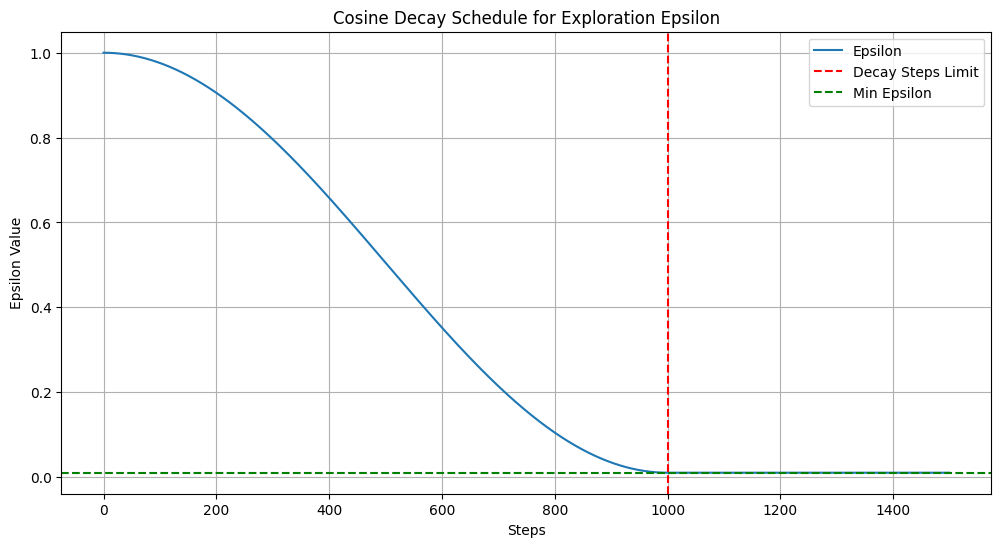

Initial epsilon: 1.0000
Mid-point epsilon (step 500): 0.5050
At decay limit (step 1000): 0.0100
After decay limit (step 1200): 0.0100


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

class Config:
    def __init__(self):
        self.explore_init_epsilon = 1.0
        self.explore_min_epsilon = 0.01
        self.explore_decay_steps = 1000

class Agent:
    def __init__(self, config):
        self.config = config
        self.iteration_count = 0
        self.explore_epsilon = config.explore_init_epsilon
        
    def update_epsilon(self):
        if self.iteration_count >= self.config.explore_decay_steps:
            self.explore_epsilon = self.config.explore_min_epsilon
        else:
            progress = self.iteration_count / self.config.explore_decay_steps
            cosine_decay = 0.5 * (1 + torch.cos(torch.tensor(progress * torch.pi))).item()
            self.explore_epsilon = (
                self.config.explore_min_epsilon
                + (self.config.explore_init_epsilon - self.config.explore_min_epsilon) * cosine_decay
            )
        
    def step(self):
        self.update_epsilon()
        self.iteration_count += 1
        return self.explore_epsilon

def run_experiment(steps=1500):
    config = Config()
    agent = Agent(config)
    
    epsilons = []
    for _ in range(steps):
        eps = agent.step()
        epsilons.append(eps)
    
    return epsilons

# Run the experiment and plot results
steps = 1500  # Run for longer than decay_steps to see behavior
epsilons = run_experiment(steps)

plt.figure(figsize=(12, 6))
plt.plot(epsilons, label='Epsilon')
plt.axvline(x=1000, color='r', linestyle='--', label='Decay Steps Limit')
plt.axhline(y=0.01, color='g', linestyle='--', label='Min Epsilon')
plt.xlabel('Steps')
plt.ylabel('Epsilon Value')
plt.title('Cosine Decay Schedule for Exploration Epsilon')
plt.grid(True)
plt.legend()
plt.show()

# Print some key values
print(f"Initial epsilon: {epsilons[0]:.4f}")
print(f"Mid-point epsilon (step 500): {epsilons[500]:.4f}")
print(f"At decay limit (step 1000): {epsilons[1000]:.4f}")
print(f"After decay limit (step 1200): {epsilons[1200]:.4f}")